<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
## <font color='blue'>Deep Learning Para Aplicações de Inteligência Artificial com Python e C++</font>
## <font color='blue'>Projeto 3</font>
## <font color='blue'>Classificação de Imagens de Satélite com Deep Learning</font>

## Instalando e Carregando os Pacotes

In [1]:
# !pip install -q -U watermark

In [2]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [3]:
# Imports
import os
import time
import shutil
import zipfile
from pathlib import Path
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import sklearn
from sklearn.metrics import confusion_matrix

print(torch.__version__)
print(torchvision.__version__)

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

# Verifica o modelo da GPU (se disponível)
if torch.cuda.is_available():
    print('Número de GPUs:', torch.cuda.device_count())
    print('Modelo GPU:', torch.cuda.get_device_name(0))
    print('Total Memória [GB] da GPU:',torch.cuda.get_device_properties(0).total_memory / 1e9)

#Reset da memória da GPU (retire a # de comentário e use somente se o ambiente tiver GPU)
from numba import cuda
device = cuda.get_current_device()
device.reset()

2.12.0+cu126
0.27.0+cu126
True
NVIDIA GeForce RTX 2060 SUPER
Número de GPUs: 1
Modelo GPU: NVIDIA GeForce RTX 2060 SUPER
Total Memória [GB] da GPU: 8.58947584


## Desafios de Visão Computacional 

### Classificação de Imagens

> A tarefa de classificação em Visão Computacional consiste em fazer com que um modelo identifique qual é a classe predominante presente em uma imagem inteira. Nesse problema, a rede neural recebe uma imagem como entrada e retorna uma ou mais categorias associadas a ela, sem indicar a localização exata dos objetos. Por exemplo, dado um conjunto de classes como “gato”, “cachorro” e “pássaro”, o modelo aprende padrões visuais — como textura, formas e cores — para prever qual classe melhor representa a imagem analisada. Arquiteturas como ResNet, VGGNet e EfficientNet são amplamente utilizadas nesse tipo de tarefa. A classificação é a base de muitos sistemas de IA, sendo aplicada em reconhecimento facial, diagnóstico médico por imagem, identificação de espécies e filtragem automática de conteúdo.

### Detecção de Objetos

> A tarefa de detecção de objetos vai além da classificação, pois o objetivo não é apenas identificar quais objetos estão presentes na imagem, mas também localizar cada objeto individualmente. Para isso, o modelo retorna classes acompanhadas de bounding boxes (caixas delimitadoras) que indicam a posição espacial dos objetos na imagem. Em um cenário de trânsito, por exemplo, o modelo pode identificar simultaneamente carros, pedestres e semáforos, desenhando uma caixa em torno de cada instância detectada. Arquiteturas como YOLO, Faster R-CNN e SSD são exemplos clássicos dessa abordagem. Esse tipo de problema é extremamente importante em carros autônomos, videomonitoramento, robótica e sistemas industriais, pois permite que a IA compreenda “onde” os objetos estão localizados no ambiente.

### Segmentação de Imagens

> A segmentação é uma tarefa ainda mais refinada, cujo objetivo é classificar cada pixel da imagem. Em vez de apenas indicar uma caixa ao redor do objeto, o modelo aprende exatamente quais pixels pertencem a cada categoria, produzindo máscaras detalhadas dos elementos presentes na cena. Existem diferentes tipos de segmentação, como a segmentação semântica — em que todos os pixels de uma mesma classe recebem o mesmo rótulo — e a segmentação por instância, que diferencia objetos individuais da mesma categoria. Modelos como U-Net, Mask R-CNN e DeepLab são amplamente utilizados nessa área. A segmentação é essencial em aplicações que exigem alta precisão espacial, como análise de tumores em exames médicos, agricultura de precisão, sensoriamento remoto e interpretação detalhada de cenas para veículos autônomos.

## Resumo de como funcionam CNNs? 


### Entendendo Como a CNN Interpreta uma Imagem

Inicialmente, uma CNN não entende objetos, bordas ou texturas. Para a rede, a imagem é apenas um tensor numérico composto por intensidades de pixels. Em imagens RGB, cada pixel possui três valores correspondentes às intensidades de vermelho (R), verde (G) e azul (B). Assim, a imagem entra na rede apenas como uma estrutura matemática organizada espacialmente.

Formalmente, uma imagem RGB pode ser representada como:

torch.Size([3, 64, 64])

| Dimensão | Significado |
| -------- | ----------- |
| 3        | canais RGB  |
| 64       | altura (H)  |
| 64       | largura (L) |


onde:

- \(3\) representa os canais RGB
- \(H\) representa a altura da imagem
- \(L) representa a largura

Isso significa 

| Eixo    | Significado | Tamanho   |
| ------- | ----------- | --------- |
| 1º eixo | canais      | 3         |
| 2º eixo | altura      | 64 pixels |
| 3º eixo | largura     | 64 pixels |

3 canais RGB

64 linhas

64 colunas

Portanto, são 3 x 64 × 64 --> cores da imagem e resolução espacial da imagem

Nesse estágio inicial, os canais ainda representam apenas cores, e não características visuais complexas.
Nesse estágio inicial, os canais ainda representam apenas cores, e não características visuais complexas.

---

### Como as Estruturas Surgem

As estruturas da imagem começam a surgir durante a operação de convolução. A CNN aplica filtros (kernels) sobre pequenas regiões locais da imagem, analisando relações espaciais entre pixels vizinhos. O objetivo desses filtros é identificar padrões matemáticos recorrentes, como mudanças bruscas de intensidade, contrastes e formas locais.

Por exemplo:

- mudanças abruptas de intensidade → bordas
- padrões repetitivos → texturas
- combinações de bordas → formas

A rede aprende automaticamente quais filtros são mais úteis durante o treinamento.

---

### Papel das Convoluções

A convolução é responsável por transformar os pixels brutos em representações mais informativas. Inicialmente, os filtros aprendem padrões simples. Conforme as camadas avançam, a rede combina padrões simples para formar representações mais complexas. Progressivamente, a CNN aprende:

- primeiras camadas:
    - bordas
    - linhas
    - contrastes

- camadas intermediárias:
    - texturas
    - curvas
    - padrões locais

- camadas profundas:
    - partes de objetos
    - formas complexas
    - objetos completos

---

### Feature Maps

Após as primeiras convoluções, os canais deixam de representar cores RGB e passam a representar mapas de características (feature maps). Ou seja:


Entrada: R, G e B

Saída das convoluções: bordas, texturas, formas e padrões aprendidos

Assim, os canais internos da CNN tornam-se representações semânticas aprendidas automaticamente pela rede: Pixels crus → padrões locais → estruturas → objetos → significado

---

## Organizando as Imagens em Disco

https://huggingface.co/datasets/blanchon/EuroSAT_RGB

In [4]:
import os
import shutil
import zipfile
from pathlib import Path

# ==========================================
# REMOVE DIRETÓRIOS ANTIGOS
# ==========================================

pastas_para_remover = [
    'EuroSAT_RGB',
    '__MACOSX',
    'imagens_treino',
    'imagens_teste'
]

for pasta in pastas_para_remover:
    
    caminho = Path(pasta)

    if caminho.exists():
        shutil.rmtree(caminho)
        print(f'Pasta removida: {pasta}')

# ==========================================
# DESCOMPACTA O DATASET
# ==========================================

arquivo_zip = 'EuroSAT_RGB.zip'

with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
    zip_ref.extractall()

print('Dataset descompactado!')

# ==========================================
# CRIA PASTAS DE TREINO E TESTE
# ==========================================

Path('imagens_treino').mkdir(exist_ok=True)
Path('imagens_teste').mkdir(exist_ok=True)

print('Pastas de treino e teste criadas!')

# ==========================================
# DEFINE CAMINHOS
# ==========================================

imagens_fonte = Path('EuroSAT_RGB')

destino_treino = Path('imagens_treino')
destino_teste = Path('imagens_teste')

Pasta removida: EuroSAT_RGB
Pasta removida: __MACOSX
Pasta removida: imagens_treino
Pasta removida: imagens_teste
Dataset descompactado!
Pastas de treino e teste criadas!


## Automatizando a Separação das Imagens em Treino e Teste

In [5]:
# SEED 
SEED = 42
random.seed(SEED)

# Variável de classe e dicionário
image_class = 0
class_dict = {}

# Cria a variável para manipular as imagens
arquivos = os.listdir(imagens_fonte)
arquivos.sort()

print(arquivos)

# Itera sobre todos os arquivos (ou diretórios) na lista 'arquivos'
for caminho_arquivo in arquivos:

    # Checa se o nome do arquivo (ou diretório) não começa com um ponto (isto é, não é um arquivo oculto)
    if caminho_arquivo[0] != '.':

        # Lista todas as imagens no diretório especificado
        images = os.listdir(imagens_fonte / caminho_arquivo)

        # Calcula o tamanho da amostra para o conjunto de treinamento (80% do total de imagens)
        sample_size = int(len(images) * 0.8)

        # Inicializa uma lista vazia para guardar os nomes das imagens de treinamento
        train = []

        # Define o destino final para as imagens de treinamento
        final_dest = destino_treino / str(image_class)

        # Cria um novo diretório para as imagens de treinamento
        os.mkdir(final_dest)

        # Seleciona uma amostra aleatória das imagens para o conjunto de treinamento e as copia para o destino final
        for file_name in random.sample(images, sample_size):
            # Copia a imagem para o diretório de destino
            shutil.copy2(os.path.join(imagens_fonte, caminho_arquivo, file_name),final_dest)

            # Adiciona o nome da imagem à lista de treinamento
            train.append(file_name)

        # Obtém a lista de imagens que não foram selecionadas para treinamento (ou seja, imagens de teste)
        test_images = list(set(images) - set(train))

        # Define o destino final para as imagens de teste
        final_dest = destino_teste / str(image_class)

        # Cria um novo diretório para as imagens de teste
        os.mkdir(final_dest)

        # Copia todas as imagens de teste para o diretório de destino
        for test_image in test_images:
            # Copia a imagem para o diretório de destino
            shutil.copy2(os.path.join(imagens_fonte, caminho_arquivo, test_image), final_dest)

        # Associa a classe da imagem ao seu respectivo caminho de arquivo no dicionário 'class_dict'
        class_dict[image_class] = caminho_arquivo

        # Incrementa o identificador da classe da imagem
        image_class += 1

['.DS_Store', 'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Pré-Processamento e Criação de Dataloaders

Imagem RGB

↓

Representação Matricial/Tensorial

↓

ToTensor()
[0,255] → [0,1]

↓

Normalize()
[0,1] → [-1,1]

↓

ImageFolder organiza:
imagem → label

↓

DataLoader cria batches

↓

Tensor entra na CNN

↓

Convolução
(extração de padrões locais)

↓

ReLU
(não-linearidade)

↓

Pooling
(redução dimensional)

↓

Flatten
(vetorização)

↓

MLP

↓

Predição Final

In [6]:
# ==========================================================
# TRANSFORMAÇÕES DAS IMAGENS VIA TORCHVISION
# ==========================================================

# O torchvision trabalha com pipelines de transformações
# aplicadas nas imagens antes que elas sejam fornecidas
# para a Rede Neural.

# A função transforms.Compose() permite encadear múltiplas
# transformações sequencialmente.

transform = transforms.Compose(
    [

        # ==========================================================
        # CONVERSÃO PARA TENSOR
        # ==========================================================

        # A transformação ToTensor() converte a imagem:
        #
        # - de PIL Image / NumPy Array
        # - para Tensor do PyTorch
        #
        # Além disso, ela realiza automaticamente uma
        # normalização dos pixels:
        #
        # Escala original RGB:
        # [0, 255]
        #
        # Nova escala após ToTensor():
        # [0.0, 1.0]
        #
        # Exemplo:
        #
        # RGB original:
        # [255, 128, 64]
        #
        # Após ToTensor():
        # [1.0, 0.5019, 0.2509]
        #
        # Isso ocorre porque o torchvision divide todos
        # os pixels por 255.

        transforms.ToTensor(),

        # ==========================================================
        # NORMALIZAÇÃO DOS PIXELS
        # ==========================================================

        # Após o ToTensor(), os pixels estão no intervalo:
        #
        # [0.0, 1.0]
        #
        # Agora aplicamos a normalização:
        #
        # x_normalizado = (x - média) / desvio_padrão
        #
        # Utilizando:
        #
        # média = 0.5
        # desvio_padrão = 0.5
        #
        # O efeito disso é transformar o intervalo:
        #
        # [0, 1] → [-1, 1]
        #
        # Exemplos:
        #
        # 0.0  → -1
        # 0.5  →  0
        # 1.0  →  1
        #
        # Isso ajuda no treinamento da Rede Neural,
        # pois redes neurais costumam convergir melhor
        # quando os dados estão centralizados próximos
        # de zero e possuem escalas menores.

        transforms.Normalize(

            # Média para os canais:
            # R, G e B
            (0.5, 0.5, 0.5),

            # Desvio padrão para os canais:
            # R, G e B
            (0.5, 0.5, 0.5)
        )
    ]
)

In [7]:
# ==========================================================
# DATASET E DATALOADER DE TREINO
# ==========================================================

# O ImageFolder é utilizado para carregar imagens organizadas em pastas, onde cada pasta representa automaticamente uma classe.
# Exemplo:
# imagens_treino/
# ├── 0/
# ├── 1/
# ├── 2/
#
# O parâmetro "transform" define as transformações que serão aplicadas nas imagens antes delas serem fornecidas ao modelo, como conversão para Tensor e normalização dos pixels.

dataset_treino = torchvision.datasets.ImageFolder(root='imagens_treino', transform=transform)

# O DataLoader é responsável por carregar as imagens em batches para o treinamento da Rede Neural.
# batch_size = 64: O modelo processará 64 imagens simultaneamente a cada iteração.
# shuffle = True: Embaralha as imagens a cada época para evitar que o modelo aprenda padrões relacionados à ordem dos dados.
# num_workers = 2: Utiliza 2 processos paralelos para acelerar o carregamento das imagens durante o treinamento.

dl_treino = torch.utils.data.DataLoader(dataset_treino,batch_size=64,shuffle=True,num_workers=2)

# ==========================================================
# DATASET E DATALOADER DE TESTE
# ==========================================================

# O dataset de teste segue a mesma lógica do treino, porém contendo imagens separadas para avaliação do desempenho do modelo.
dataset_teste = torchvision.datasets.ImageFolder( root='imagens_teste', transform=transform)

# No DataLoader de teste utilizamos batch_size = 1, permitindo avaliar uma imagem por vez durante as inferências e métricas de avaliação.
dl_teste = torch.utils.data.DataLoader(dataset_teste,batch_size=1,shuffle=True,num_workers=2)

In [8]:
print(dataset_treino)
print(dl_treino)

Dataset ImageFolder
    Number of datapoints: 21600
    Root location: imagens_treino
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )


## Visualizando as Imagens

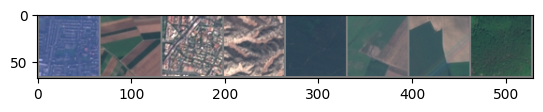

Labels: 7 0 7 2 1 0 0 1


In [9]:
# Função para visualizar imagens
def imshow(img):

    # Carrega e normaliza a imagem
    img = img / 2 + 0.5

    # Converte a imagem em array numpy
    npimg = img.numpy()

    # Mostra a imagem
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Obtém um lote de imagens
dataiter = iter(dl_treino)
images, labels = next(dataiter)

# Mostra a imagem
imshow(torchvision.utils.make_grid(images[:8]))
print('Labels:', ' '.join('%d' % labels[j] for j in range(8)))

# Faz o Mapeamento de Classes
mapeamento = {0:'AnnualCrop',
              1:'Forest',
              2:'HerbaceousVegetation',
              3:'Highway',
              4:'Industrial',
              5:'Pasture',
              6:'PermanentCrop',
              7:'Residential',
              8:'River',
              9:'SeaLake'}

## Modelagem - Construção do Modelo de Deep Learning

# Comparação Entre as Arquiteturas CNN

A arquitetura original possuía uma estrutura muito mais pesada computacionalmente, principalmente devido ao tamanho extremamente elevado da camada densa após o `flatten`. Como o pooling era aplicado apenas ao final das convoluções, os mapas de características mantinham dimensões espaciais muito grandes durante quase toda a rede, fazendo com que o vetor achatado gerado para a MLP fosse gigantesco.

Fluxo da arquitetura original:

```text
Conv → Conv → Conv → Pool → Flatten Gigante → Dense Gigante
```

A principal consequência disso foi a criação de uma camada extremamente custosa:

```python
Linear(215296, 2048)
```

Essa estrutura gera centenas de milhões de parâmetros, aumentando drasticamente:

- consumo de RAM/VRAM
- tempo de treinamento
- risco de overfitting
- custo computacional

Apesar disso, a arquitetura original possui maior capacidade representacional, pois contém mais filtros e mais parâmetros treináveis.

---

A arquitetura otimizada foi reformulada para reduzir o custo computacional e tornar o treinamento mais viável. O principal ajuste foi distribuir o `MaxPooling` ao longo da rede, reduzindo gradualmente as dimensões espaciais dos mapas de características.

Fluxo da arquitetura otimizada:

```text
Conv → Pool
Conv → Pool
Conv → Pool
Flatten Menor → Dense Menor
```

Além disso, o número de filtros convolucionais foi reduzido:

```python
32 → 64 → 128
```

e a MLP passou a trabalhar com um vetor muito menor:

```python
Linear(128 * 16 * 16, 512)
```

Isso reduz drasticamente:

- número de parâmetros
- consumo de memória
- tempo de treinamento
- risco de overfitting

A nova arquitetura mantém a lógica hierárquica das CNNs — aprendendo bordas, texturas e padrões mais complexos — porém de forma muito mais eficiente e estável computacionalmente.

---

## Trade-off Entre as Arquiteturas

| Aspecto | Arquitetura Original | Arquitetura Otimizada |
|---|---|---|
| Capacidade de representação | Maior | Moderada |
| Número de parâmetros | Muito alto | Muito menor |
| Tempo de treino | Muito lento | Muito mais rápido |
| Consumo de memória | Muito alto | Muito menor |
| Risco de overfitting | Alto | Menor |
| Estabilidade computacional | Baixa | Muito melhor |

---

Em termos práticos, a arquitetura original prioriza poder de representação, enquanto a arquitetura otimizada busca equilíbrio entre desempenho e eficiência computacional. Em muitos cenários reais, arquiteturas menores e mais bem estruturadas tendem a apresentar melhor custo-benefício e treinamento mais estável.

In [10]:
# # =========================================================
# # DEFINIÇÃO DA ARQUITETURA DA CNN
# # =========================================================

# # Define uma nova classe chamada DSANet
# # Toda rede neural no PyTorch herda de nn.Module
# class DSANet(nn.Module):

#     # =====================================================
#     # CONSTRUTOR DA REDE
#     # Aqui definimos TODAS as camadas da arquitetura
#     # =====================================================
#     def __init__(self):

#         # Inicializa a classe pai (nn.Module)
#         super(DSANet, self).__init__()

#         # =================================================
#         # BLOCO CONVOLUCIONAL
#         # Responsável por extrair padrões da imagem
#         # =================================================

#         # Primeira convolução
#         # Entrada: 3 canais RGB
#         # Saída: 64 feature maps
#         # Kernel: 3x3
#         # Stride: 1
#         # O stride define quantos pixels o kernel "anda" a cada convolução. Stride = 1 O filtro anda pixel por pixel:
#         # [ X X X ] 
#         #   ↓ 1 pixel
#         # Intuição: aprende padrões simples: bordas, linhas e contrastes

#         self.conv1 = nn.Conv2d(3, 64, 3, 1)

#         # Segunda convolução
#         # Entrada: 64 feature maps
#         # Saída: 128 feature maps
#         # Intuição: aprende padrões mais complexos combinando padrões anteriores
#         self.conv2 = nn.Conv2d(64, 128, 3, 1)

#         # Terceira convolução
#         # Entrada: 128 feature maps
#         # Saída: 256 feature maps
#         # Intuição: aprende estruturas mais abstratas como formas e regiões relevantes
#         self.conv3 = nn.Conv2d(128, 256, 3, 1)

#         # =================================================
#         # REGULARIZAÇÃO
#         # Dropout ajuda a evitar overfitting
#         # =================================================

#         # Dropout de 25%
#         # Durante o treino: desliga aleatoriamente 25% dos neurônios
#         self.dropout1 = nn.Dropout(0.25)

#         # Dropout de 50%
#         # Regularização mais forte
#         self.dropout2 = nn.Dropout(0.5)

#         # =================================================
#         # CAMADAS DENSAS (MLP)
#         # Responsáveis pela classificação final
#         # =================================================

#         # Primeira camada totalmente conectada
#         # Entrada: vetor achatado vindo das convoluções
#         # Saída: 2048 neurônios
#         self.fc1 = nn.Linear(215296, 2048)

#         # Segunda camada densa
#         # Saída: 512 neurônios
#         self.fc2 = nn.Linear(2048, 512)

#         # Terceira camada densa
#         # Saída: 128 neurônios
#         self.fc3 = nn.Linear(512, 128)

#         # Camada de saída
#         #
#         # Saída:
#         # 10 neurônios → 10 classes
#         self.fc4 = nn.Linear(128, 10)

#     # =====================================================
#     # FORWARD PASS
#     # Define como os dados percorrem a rede
#     # =====================================================
#     def forward(self, x):

#         # =================================================
#         # ETAPA 1 — PRIMEIRA CONVOLUÇÃO
#         # =================================================

#         # Aplica a convolução
#         x = self.conv1(x)

#         # Ativação ReLU: Remove valores negativos e introduz não-linearidade
#         x = F.relu(x)

#         # =================================================
#         # ETAPA 2 — SEGUNDA CONVOLUÇÃO
#         # =================================================

#         x = self.conv2(x)

#         # Ativação ReLU: Remove valores negativos e introduz não-linearidade
#         x = F.relu(x)

#         # =================================================
#         # ETAPA 3 — TERCEIRA CONVOLUÇÃO
#         # =================================================

#         x = self.conv3(x)

#         # Ativação ReLU: Remove valores negativos e introduz não-linearidade
#         x = F.relu(x)

#         # =================================================
#         # ETAPA 4 — MAX POOLING
#         # =================================================

#         # Reduz a dimensionalidade espacial
#         # Kernel 2x2: reduz altura e largura pela metade
#         # Mantém apenas as ativações mais fortes
#         x = F.max_pool2d(x, 2)

#         # =================================================
#         # ETAPA 5 — DROPOUT
#         # =================================================

#         # Desliga neurônios aleatoriamente para evitar overfitting
#         x = self.dropout1(x)

#         # =================================================
#         # ETAPA 6 — FLATTEN
#         # =================================================

#         # Converte tensor 3D em vetor 1D
#         # CNN → MLP
#         # Exemplo: [batch, canais, altura, largura] vira [batch, vetor]
#         x = torch.flatten(x, 1)

#         # =================================================
#         # ETAPA 7 — PRIMEIRA CAMADA DENSA
#         # =================================================

#         x = self.fc1(x)

#         # Ativação ReLU: Remove valores negativos e introduz não-linearidade
#         x = F.relu(x)

#         # =================================================
#         # ETAPA 8 — DROPOUT
#         # =================================================

#         x = self.dropout2(x)

#         # =================================================
#         # ETAPA 9 — SEGUNDA CAMADA DENSA
#         # =================================================

#         x = self.fc2(x)

#         # Ativação ReLU: Remove valores negativos e introduz não-linearidade
#         x = F.relu(x)

#         # =================================================
#         # ETAPA 10 — TERCEIRA CAMADA DENSA
#         # =================================================

#         x = self.fc3(x)

#         # Ativação ReLU: Remove valores negativos e introduz não-linearidade
#         x = F.relu(x)

#         # =================================================
#         # ETAPA 11 — CAMADA DE SAÍDA
#         # =================================================

#         # Produz logits para as 10 classes
#         x = self.fc4(x)

#         # =================================================
#         # ETAPA 12 — SOFTMAX
#         # =================================================

#         # Converte logits em probabilidades
#         # dim = 1:
#         # aplica sobre as classes
#         return F.log_softmax(x, dim = 1)

In [18]:
# =========================================================
# DEFINIÇÃO DA ARQUITETURA DA CNN
# =========================================================

# Define uma nova classe chamada DSANet
# Toda rede neural no PyTorch herda de nn.Module
class DSANet(nn.Module):

    # =====================================================
    # CONSTRUTOR DA REDE
    # Aqui definimos TODAS as camadas da arquitetura
    # =====================================================
    def __init__(self):

        # Inicializa a classe pai (nn.Module)
        super(DSANet, self).__init__()

        # =================================================
        # BLOCO CONVOLUCIONAL
        # Responsável por extrair padrões da imagem
        # =================================================

        # Primeira convolução
        # Entrada: 3 canais RGB
        # Saída: 32 feature maps
        # Kernel: 3x3
        # Stride: 1. O stride define quantos pixels o kernel "anda" a cada convolução. Stride = 1 → o filtro anda pixel por pixel.
        # Padding: 1. O padding adiciona pixels extras (preenchidos com zeros) nas bordas da imagem para preservar as dimensões após a convolução. Com kernel 3x3 e padding 1, a saída terá a mesma altura e largura da entrada.
        # Intuição: aprende padrões simples como bordas, linhas e contrastes
        self.conv1 = nn.Conv2d(3, 32, 3, 1, padding = 1)

        # Segunda convolução
        # Entrada: 32 feature maps
        # Saída: 64 feature maps
        # Intuição: combina padrões anteriores para aprender texturas e formas
        self.conv2 = nn.Conv2d(32, 64, 3, 1, padding = 1)

        # Terceira convolução
        # Entrada: 64 feature maps
        # Saída: 128 feature maps
        # Intuição: aprende estruturas mais abstratas e regiões relevantes
        self.conv3 = nn.Conv2d(64, 128, 3, 1, padding = 1)

        # =================================================
        # REGULARIZAÇÃO
        # Dropout ajuda a evitar overfitting
        # =================================================

        # Dropout de 25%
        # Durante o treino: desliga aleatoriamente 25% dos neurônios
        self.dropout1 = nn.Dropout(0.25)

        # Dropout de 50%
        # Regularização mais forte
        self.dropout2 = nn.Dropout(0.5)

        # =================================================
        # CAMADAS DENSAS (MLP)
        # Responsáveis pela classificação final
        # =================================================

        # Primeira camada totalmente conectada
        # A entrada será muito menor após os poolings
        self.fc1 = nn.Linear(8192, 512)

        # Segunda camada densa
        self.fc2 = nn.Linear(512, 128)

        # Camada de saída
        # 10 neurônios → 10 classes
        self.fc3 = nn.Linear(128, 10)

    # =====================================================
    # FORWARD PASS
    # Define como os dados percorrem a rede
    # =====================================================
    def forward(self, x):

        # =================================================
        # ETAPA 1 — PRIMEIRA CONVOLUÇÃO
        # =================================================

        # Convolução + ReLU
        x = F.relu(self.conv1(x))

        # Max Pooling
        # Reduz altura e largura pela metade
        x = F.max_pool2d(x, 2)

        # =================================================
        # ETAPA 2 — SEGUNDA CONVOLUÇÃO
        # =================================================

        # Convolução + ReLU
        x = F.relu(self.conv2(x))

        # Max Pooling
        x = F.max_pool2d(x, 2)

        # =================================================
        # ETAPA 3 — TERCEIRA CONVOLUÇÃO
        # =================================================

        # Convolução + ReLU
        x = F.relu(self.conv3(x))

        # Max Pooling
        x = F.max_pool2d(x, 2)

        # =================================================
        # ETAPA 4 — DROPOUT
        # =================================================

        # Desliga neurônios aleatoriamente
        x = self.dropout1(x)

        # =================================================
        # ETAPA 5 — FLATTEN
        # =================================================

        # CNN → vetor 1D
        x = torch.flatten(x, 1)

        # =================================================
        # ETAPA 6 — PRIMEIRA CAMADA DENSA
        # =================================================

        # Camada densa + ReLU
        x = F.relu(self.fc1(x))

        # Dropout
        x = self.dropout2(x)

        # =================================================
        # ETAPA 7 — SEGUNDA CAMADA DENSA
        # =================================================

        # Camada densa + ReLU
        x = F.relu(self.fc2(x))

        # =================================================
        # ETAPA 8 — CAMADA DE SAÍDA
        # =================================================

        # Produz logits para as classes
        x = self.fc3(x)

        # Converte logits em probabilidades
        return F.log_softmax(x, dim = 1)

In [19]:
# Cria o modelo
modelo = DSANet()
print(modelo)

# Define o device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# Manda o modelo para o device
modelo.to(device)

DSANet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
cuda:0


DSANet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

## Selecionando a Função de Erro

In [20]:
# Função de erro
criterion = nn.CrossEntropyLoss()

## Selecionando o Otimizador

In [21]:
# Otimizador
optimizer = optim.Adam(modelo.parameters())

## Treinamento do Modelo

In [22]:
%%time
print('Treinamento Iniciado!')

# Número de épocas: Aumente o número de épocas para obter um modelo mais preciso, Diminua o número de épocas para treinar mais rápido
num_epochs = 5

# Iteração de teste
testiter = iter(dl_teste)

# Itera sobre o número de épocas
for epoch in range(num_epochs):

    # Inicializa a variável que acumula a perda ao longo da época
    running_loss = 0.0

    # Inicializa um contador para os batches
    i = 0

    # Itera sobre os dados de treinamento com uma barra de progresso (tqdm)
    for data in (pbar := tqdm(dl_treino)):

        # Atualiza a descrição da barra de progresso para mostrar a época atual
        pbar.set_description(f"\nEpoch {epoch}")

        # Descompacta o batch de dados em entradas e rótulos
        inputs, labels = data

        # Move as entradas e rótulos para o dispositivo correto (CPU ou GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zera os gradientes do otimizador
        optimizer.zero_grad()

        # Realiza a passagem para frente através da rede neural
        outputs = modelo(inputs)

        # Calcula a perda usando o critério definido
        loss = criterion(outputs, labels)

        # Realiza a passagem para trás para calcular os gradientes
        loss.backward()

        # Atualiza os pesos da rede neural usando o otimizador
        optimizer.step()

        # Atualiza o valor acumulado da perda
        running_loss += loss.item()

        # Inicializa contadores para o número correto de previsões e o número total de amostras
        total_correct = 0
        total_samples = 0

        # Se estamos em um batch múltiplo de 100
        if i % 100 == 0:

            # Desativa o cálculo dos gradientes para economizar memória e tempo de processamento
            with torch.no_grad():

                # Obtém um batch de imagens e rótulos de teste
                test_images, test_labels = next(testiter)
                test_images, test_labels = test_images.to(device), test_labels.to(device)

                # Realiza uma passagem para frente na rede neural com as 8 imagens de teste
                test_outputs = modelo(test_images[:8])

                # Obtem as previsões para as 8 imagens
                _, predicted = torch.max(test_outputs, 1)

        # Incrementa o contador de batches
        i += 1

    # Exibe a perda média para a época
    print(f"Epoch {epoch}, Loss: {running_loss / (i)}")

print('Treinamento Concluído!')

Treinamento Iniciado!


Epoch 0: 100%|██████████| 338/338 [00:49<00:00,  6.76it/s]


Epoch 0, Loss: 1.2389477034644967


Epoch 1: 100%|██████████| 338/338 [00:11<00:00, 30.65it/s]


Epoch 1, Loss: 0.7213239445841524


...

Epoch 2, Loss: 0.5697662466641008


Epoch 3: 100%|██████████| 338/338 [00:10<00:00, 31.02it/s]


Epoch 3, Loss: 0.4901337266938221


Epoch 4: 100%|██████████| 338/338 [00:11<00:00, 30.55it/s]

Epoch 4, Loss: 0.4131751588639423
Treinamento Concluído!
CPU times: total: 20.7 s
Wall time: 1min 40s


## Avaliação do Modelo

In [ ]:
# Inicializa os contadores
total_correct = 0
total_samples = 0

# Coloca o modelo em modo de avaliação (isso desativa camadas como dropout e batch normalization)
modelo.eval()

# Desativa o cálculo dos gradientes para economizar memória e tempo de processamento
with torch.no_grad():

    # Itera sobre os dados de teste com uma barra de progresso (tqdm)
    for data in (pbar := tqdm(dl_teste)):

        # Atualiza a descrição da barra de progresso para mostrar "Avaliando o Modelo"
        pbar.set_description(f"Avaliando o Modelo.")

        # Descompacta o batch de dados em entradas e rótulos
        inputs, labels = data

        # Move as entradas e rótulos para o dispositivo correto (CPU ou GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Realiza a passagem para frente através do modelo
        outputs = modelo(inputs)

        # Obtem a classe prevista (índice do valor máximo) para cada entrada no batch
        _, predicted = torch.max(outputs.data, 1)

        # Incrementa o total de amostras pelo número de rótulos no batch atual
        total_samples += labels.size(0)

        # Incrementa o total de previsões corretas pelo número de previsões corretas no batch atual
        total_correct +=  (predicted == labels).sum().item()

Avaliando o Modelo.: 100%|██████████| 5400/5400 [00:20<00:00, 260.72it/s]


In [25]:
# Calcula a acurácia
accuracy = total_correct/total_samples
print(accuracy)

0.8848148148148148


## Deploy e Uso do Modelo

Classe Real: SeaLake
Classe Prevista: SeaLake
Acertou? True


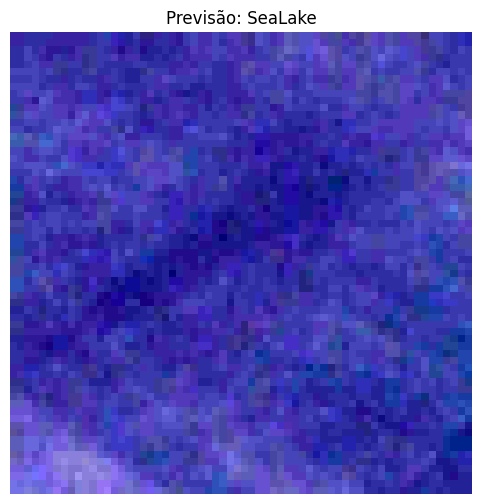

In [28]:
# Faz o Mapeamento de Classes
mapeamento = {
    0:'AnnualCrop',
    1:'Forest',
    2:'HerbaceousVegetation',
    3:'Highway',
    4:'Industrial',
    5:'Pasture',
    6:'PermanentCrop',
    7:'Residential',
    8:'River',
    9:'SeaLake'
}

# Coloca o modelo em modo de avaliação
with torch.no_grad():

    # Obtém um batch do dataset de teste
    data_iter = iter(dl_teste)
    inputs, labels = next(data_iter)

    # Seleciona a primeira imagem
    imagem = inputs[0].unsqueeze(0)

    # Label real
    label_real = labels[0].item()

    # Move para GPU/CPU
    imagem = imagem.to(device)

    # Faz previsão
    outputs = modelo(imagem)

    # Obtém classe prevista
    _, predicted = torch.max(outputs, 1)

    # Classe prevista
    classe_prevista = predicted.item()

    # Verifica acerto
    acertou = classe_prevista == label_real

    print("Classe Real:", mapeamento[label_real])
    print("Classe Prevista:", mapeamento[classe_prevista])
    print("Acertou?", acertou)

    # Converte a imagem para formato numpy para visualização
    # Move a imagem de volta para CPU e converte para numpy
    imagem_numpy = imagem.cpu().numpy()[0]

    # As imagens normalmente estão no formato [C, H, W], então você precisa reordenar para [H, W, C] para a visualização
    # Isso também depende do tipo de dados da imagem, pode ser necessário normalizar ou ajustar o range para visualização correta
    imagem_numpy = np.transpose(imagem_numpy, (1, 2, 0))

    # Ajusta os canais de imagem se necessário (por exemplo, se estiver em escala de cinza ou se a normalização foi aplicada)
    if imagem_numpy.shape[2] == 1:  # Imagens em escala de cinza
        imagem_numpy = np.squeeze(imagem_numpy, axis=2)
    elif imagem_numpy.shape[2] == 3:  # Imagens RGB
        imagem_numpy = (imagem_numpy - imagem_numpy.min()) / (imagem_numpy.max() - imagem_numpy.min())  # Normaliza para 0-1 se necessário

    plt.figure(figsize=(6, 6))
    plt.imshow(imagem_numpy)
    plt.title(f'Previsão: {mapeamento[predicted.item()]}')
    plt.axis('off')
    plt.show()

In [ ]:
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [ ]:
#%watermark -v -m

In [ ]:
#%watermark --iversions

# Fim